In [234]:
import torch 
import torch.nn as nn
import torch.nn.functional as F 

In [235]:

class Model(nn.Module):
    # takeing input from where -> layer 1 of neurons -> layer 2 -> output 
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        super().__init__()
        self.fc1 = nn.Linear(in_features,h1)
        self.fc2 = nn.Linear(h1,h2)
        self.out = nn.Linear(h2,out_features)

    def forward(self, x):
        x=F.relu(self.fc1(x)) #rectified linear unit(relu)
        x=F.relu(self.fc2(x))
        x= self.out(x)

        return x
    

In [236]:
# manual seed for randomisation
torch.manual_seed(41)
# creat an instance of model 
model = Model()

In [237]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline 

In [238]:
url="https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv"
my_df = pd.read_csv(url)


In [259]:
my_df['species'] = my_df['species'].replace({
    'setosa': 0.0,
    'versicolor': 1.0,
    'virginica': 2.0
})
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [240]:
x = my_df.drop("species", axis=1)  

y = my_df["species"] 


In [241]:
x=x.values
y=y.values

In [242]:
from sklearn.model_selection import train_test_split

In [243]:
x_train, x_test, y_train, y_test = train_test_split(x ,y ,test_size=0.2 ,random_state=41)

In [244]:
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)


In [245]:
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [246]:
#Set  the criteria of model to measire the erroe how farr off the prection are from the data 
criterion = nn.CrossEntropyLoss()
#choose adam optimiser , lr= learning rate (if error dosent go down after bunch of iterations , lower our learning rate  )
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

In [247]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [248]:
#Train to model
#epochs(one run thru all the traning data in  our network)
epochs = 200 
losses =[]
for i in range (epochs):
    #go forward and a prediction 
    y_pred = model.forward(x_train) #get predicted result 
    #measure the loss/error , gonna be high at first 
    loss = criterion(y_pred, y_train) # predicted values as the y train 
    # keep track of our losses 
    losses.append(loss.detach().numpy())

    #print every 10 epochs
    if i % 10 ==0:
        print(f'epoch: {i}and loss: {loss}')
    #do some back progation take the error rate of forward  propogation and feed it back thrugh the network to fine tune the weights 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    

    

epoch: 0and loss: 1.1251550912857056
epoch: 10and loss: 1.0096259117126465
epoch: 20and loss: 0.8157405257225037
epoch: 30and loss: 0.585706353187561
epoch: 40and loss: 0.3999636471271515
epoch: 50and loss: 0.26768800616264343
epoch: 60and loss: 0.17942363023757935
epoch: 70and loss: 0.12151691317558289
epoch: 80and loss: 0.0860118493437767
epoch: 90and loss: 0.06520850956439972
epoch: 100and loss: 0.052865754812955856
epoch: 110and loss: 0.04508380591869354
epoch: 120and loss: 0.0397995188832283
epoch: 130and loss: 0.03597070649266243
epoch: 140and loss: 0.0329371802508831
epoch: 150and loss: 0.0304193664342165
epoch: 160and loss: 0.02679518237709999
epoch: 170and loss: 0.023382510989904404
epoch: 180and loss: 0.020531879737973213
epoch: 190and loss: 0.018495608121156693


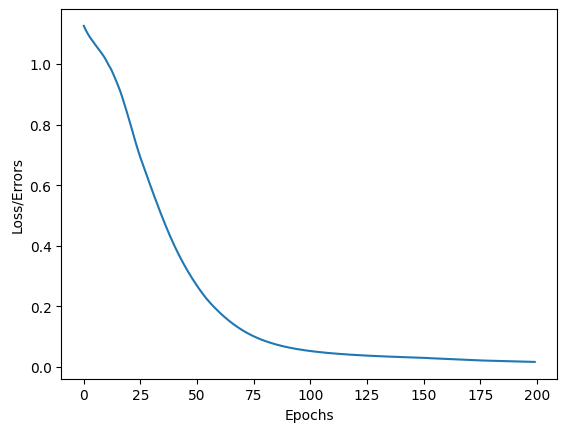

In [249]:
#graph it out!
plt.plot(range(epochs), losses)
plt.ylabel("Loss/Errors")
plt.xlabel("Epochs")
plt.show()

In [257]:
correct = 0
with torch.no_grad():
    for i, data in enumerate(x_test):
        y_val = model.forward(data)
        if y_test[i]==0:
            x="setosa"
        elif y_test[i]==1:
            x="cersicolor"
        else:
            x="virginica"
        
        print(f'{i+1}.) {str(y_val)} \t {y_test[i]}') # type of flower

        #correct or not
        if y_val.argmax().item() == y_test[i]:
            correct+=1
print(f'we got',correct,"correct")
        

1.) tensor([-7.1090,  3.8946,  9.0007]) 	 2
2.) tensor([-9.7568,  1.8037, 15.7613]) 	 2
3.) tensor([-10.9674,   2.8778,  16.6033]) 	 2
4.) tensor([-3.7643,  8.0392, -1.2695]) 	 1
5.) tensor([-9.0331,  3.5239, 12.6381]) 	 2
6.) tensor([-1.8243,  8.6935, -5.3428]) 	 1
7.) tensor([-6.8733,  4.9822,  7.3701]) 	 2
8.) tensor([-3.6488,  8.2260, -1.6746]) 	 1
9.) tensor([-7.9281,  4.2589,  9.9573]) 	 2
10.) tensor([-10.4297,   1.8742,  16.8125]) 	 2
11.) tensor([-6.4725,  5.1595,  6.5084]) 	 2
12.) tensor([ 12.4419,   2.4570, -21.9054]) 	 0
13.) tensor([ 11.4217,   2.2045, -19.9141]) 	 0
14.) tensor([-0.1939,  6.9626, -6.0927]) 	 1
15.) tensor([ 10.1568,   3.3059, -19.1093]) 	 0
16.) tensor([-5.9766,  5.7990,  4.9672]) 	 2
17.) tensor([ 11.2092,   2.5254, -19.9657]) 	 0
18.) tensor([-6.8897,  4.2925,  8.1946]) 	 1
19.) tensor([ 12.0366,   2.3664, -21.1265]) 	 0
20.) tensor([  9.6811,   2.7818, -17.7343]) 	 0
21.) tensor([-0.8225,  7.6358, -5.8092]) 	 1
22.) tensor([-10.0604,   2.6577,  15.336

In [265]:
# ecaluate NEW DATA INSIDE THE ON THE NETWORK 

In [266]:
new_iris = torch.tensor([4.7,3.2,1.3,0.2])

In [267]:
with torch.no_grad():
    print(model(new_iris))

tensor([ 12.1671,   2.2441, -21.1880])


In [268]:
#TO SAVE OUR MODEL 
torch.save(model.state_dict(),"iris_nerual_network.pt")

In [269]:
#load my model
new_model = Model()
new_model.load_state_dict(torch.load("iris_nerual_network.pt"))

<All keys matched successfully>

In [271]:
#check its loaded orrectly 
new_model.eval() 


Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)

In [272]:
print("fc1 first layer , fc2 second layer , out is output")


fc1 first layer , fc2 second layer , out is output
